<a href="https://colab.research.google.com/github/sandeepmohamed666/ICTAK_B9_Python-Case-Study/blob/main/(Case_Study)_Machine_Learning_(Unsupervised)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Q** . **Problem Statement :** **Socioeconomic Group Discovery using Census Data**

**Context:**

You've been hired by a policy think tank to help identity latent socioeconomic
segments in the adult population of the United States using 1994 census data. Instead
of using predefined Income labels (like >50K), your goal is to discover hidden clusters
based solely on people's demographics and working habits.

**Objective:**

Use unsupervised learning techniques (e.g., clustering) to identify distinct groups in the
adult population. These clusters can help in designing better-targeted welfare schemes,
employment programs, and financial literacy Campaigns.

**Dataset Overview:**

You are provided a dataset with the following attributes:
                     
**Type** : Numerical, **Features :** age, fnlwgt, education—num, capital—gain, capital-loss, hours-per-week ;

**Type :** Categorical, **Features :** workclass, education, marital-status, occupation, relationship, race,sex, native-country

The dataset contains missing values (e.g., in occupation, Workclass) and outliers
(e.g., in age, hours-per-week) that need to be handled.


# Importing Libraries  

In [ ]:
from IPython.core import prefilter # importing the prefilter module from IPython’s internal core system. (step that happens before your code is actually executed.)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# used for scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder

# For PCA
from sklearn.decomposition import PCA

# For TSNE
from sklearn.manifold import TSNE

# For silhouette_score
from sklearn.metrics import silhouette_score

# clustering (KMeans)
from sklearn.cluster import KMeans

# Clustering (Agglomerative)
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage # dendrogram

# For preprocessing pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Loading & Reading Dataset

In [ ]:
filepath = '/content/drive/MyDrive/ICTAK-DSA-B9/----Case study + Live Coding----/-z1) Machine-Learning Algorithm Unsupervised/adult_dataset (1).csv'
df_adult = pd.read_csv(filepath)
df_adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


# Dataset Overview

## i) Exploring the data

In [ ]:
# info() - to know the data type ,know the null values from non null values...i.e the remainig

df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [ ]:
# describe() - to give an statistical information from the dataset

df_adult.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


# Tasks :

# I) Data Preprocessing

## 1) Replace '?' and NaN values appropriately (mode for categorical, mean/medien for numerical)


### a) Replacing '?' with NaN values

In [ ]:
# Before Replacing '?' with NaN values

In [ ]:
# Checking String Character '?' in the Columns
print(df_adult['age'].unique(),'\n')
print(df_adult['workclass'].unique(),'\n')
print(df_adult['fnlwgt'].unique(),'\n')
print(df_adult['education'].unique(),'\n')
print(df_adult['marital-status'].unique(),'\n')
print(df_adult['occupation'].unique(),'\n')
print(df_adult['relationship'].unique(),'\n')
print(df_adult['race'].unique(),'\n')
print(df_adult['sex'].unique(),'\n')
print(df_adult['capital-gain'].unique(),'\n')
print(df_adult['hours-per-week'].unique(),'\n')
print(df_adult['native-country'].unique(),'\n')
print(df_adult['income'].unique(),'\n')

[ 39.  50.  38.  53.  28.  37.  49.  52.  31.  42.  30.  23.  32.  40.
  34.  25.  nan  54.  35.  43.  59.  56.  19.  20.  45.  22.  48.  21.
  24.  57.  44.  41.  29.  18.  47.  46.  79.  27.  67.  33.  76.  17.
 120.  36.  55.  61.  70.  64.  71.  68.  66.  51.  58.  26.  60.  90.
  75.  65.  77.  62.  63.  80.  74.  72.  69.  73.  81.  88. 250.  78.
  82.  83. 255.  84.  85. 225. 230.  86.  87.  89. 140. 100. 210.] 

['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' nan 'Local-gov'
 '?' 'Self-emp-inc' 'Without-pay' 'Never-worked'] 

[ 77516  83311 215646 ... 173449  89686 350977] 

['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th'] 

['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed'] 

['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair'

In [ ]:
# Detected String Character '?' in workclass ,occupation & native-country

In [ ]:
# Replacing '?' with nan
df_adult.replace('?', np.nan, inplace=True)

In [ ]:
# After Replacing '?' with NaN values

In [ ]:
# Checking String Character '?' in the Columns
print(df_adult['age'].unique(),'\n')
print(df_adult['workclass'].unique(),'\n')
print(df_adult['fnlwgt'].unique(),'\n')
print(df_adult['education'].unique(),'\n')
print(df_adult['marital-status'].unique(),'\n')
print(df_adult['occupation'].unique(),'\n')
print(df_adult['relationship'].unique(),'\n')
print(df_adult['race'].unique(),'\n')
print(df_adult['sex'].unique(),'\n')
print(df_adult['capital-gain'].unique(),'\n')
print(df_adult['hours-per-week'].unique(),'\n')
print(df_adult['native-country'].unique(),'\n')
print(df_adult['income'].unique(),'\n')

[ 39.  50.  38.  53.  28.  37.  49.  52.  31.  42.  30.  23.  32.  40.
  34.  25.  nan  54.  35.  43.  59.  56.  19.  20.  45.  22.  48.  21.
  24.  57.  44.  41.  29.  18.  47.  46.  79.  27.  67.  33.  76.  17.
 120.  36.  55.  61.  70.  64.  71.  68.  66.  51.  58.  26.  60.  90.
  75.  65.  77.  62.  63.  80.  74.  72.  69.  73.  81.  88. 250.  78.
  82.  83. 255.  84.  85. 225. 230.  86.  87.  89. 140. 100. 210.] 

['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' nan 'Local-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked'] 

[ 77516  83311 215646 ... 173449  89686 350977] 

['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th'] 

['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed'] 

['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Tr

In [ ]:
# Replaced String Character '?' in workclass ,occupation & native-country with nan

### b) Checking for missing Value

In [ ]:
df_adult.isna() # df_adult.isnull()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
48838,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False
48839,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
48840,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df_adult.isna().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [ ]:
# Calculating the Percentage of missing values in each column (sorted)

missing_percent = df_adult.isna().sum()/ len(df_adult)   # Have clear understanding   # Important you should check  # Evidence to show for Replacement
missing_percent.sort_values(ascending = True)                  # Wheter Symmetrical, Skewed or Non-Symmetric

,0
education,0.000000
fnlwgt,0.000000
marital-status,0.000000
education-num,0.000000
relationship,0.000000
capital-gain,0.000000
sex,0.000000
race,0.000000
income,0.000000
capital-loss,0.000000


### c) Splitting of Columns (Data)

In [ ]:
# Splitting the Columns into Numerical & Categorical Columns

num_cols = df_adult.select_dtypes(include= ['number'])     # It returns the actual data (DataFrame) containing those columns.
cat_cols = df_adult.select_dtypes(include= ['object'])

In [ ]:
num_cols

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
0,39.0,77516,13,2174,0,40.0
1,50.0,83311,13,0,0,13.0
2,38.0,215646,9,0,0,40.0
3,53.0,234721,7,0,0,40.0
4,28.0,338409,13,0,0,40.0
...,...,...,...,...,...,...
48837,39.0,215419,13,0,0,36.0
48838,64.0,321403,9,0,0,40.0
48839,38.0,374983,13,0,0,50.0
48840,44.0,83891,13,5455,0,40.0


In [ ]:
cat_cols

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,NaN,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...
48837,Private,Bachelors,Divorced,Prof-specialty,Not-in-family,White,Female,United-States,<=50K.
48838,NaN,HS-grad,Widowed,NaN,Other-relative,Black,Male,United-States,<=50K.
48839,Private,Bachelors,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K.
48840,Private,Bachelors,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,United-States,<=50K.


In [ ]:
# since we want only the columns not full data for missing value
num_cols = df_adult.select_dtypes(include= ['number']).columns
cat_cols = df_adult.select_dtypes(include= ['object']).columns

In [ ]:
num_cols

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [ ]:
cat_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')

### d) Plotting data Distribution in Numerical Columns

In [ ]:
# Plot and subplot for 6 columns in num_cols

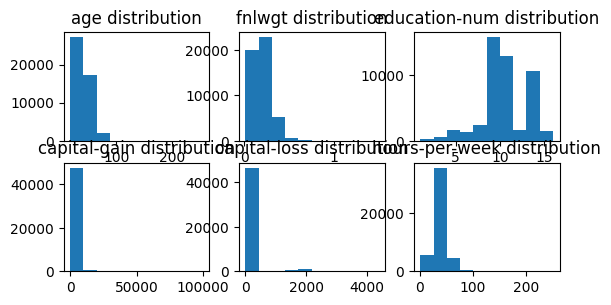

In [ ]:
# using iterative methods to plot all histograms in a single plot
for i,col in enumerate(num_cols, 1):
  plt.subplot(3,3,i)
  plt.hist(df_adult[col])            # age distribution income distribution  kaanan
  plt.title(col+ " distribution")

plt.show()

In [ ]:
df_adult[num_cols].skew()

,0
age,0.975599
fnlwgt,1.438892
education-num,-0.316525
capital-gain,11.894659
capital-loss,4.569809
hours-per-week,0.786119


In [ ]:
# ----------------------------
# Interpretation
# ----------------------------
# 0 → normal distribution
# > 1 → highly right-skewed
# < -1 → highly left-skewed

# ---------------------------------------------------------
#    Interpretation of Census Dataset Histograms
# ---------------------------------------------------------
#               Typical observations:
# ---------------------------------------------------------
#     Column	               Distribution Insight
# ----------------------------------------------------------
#      age	                Slightly right-skewed
#    fnlwgt	                  Highly skewed
# education-num	          Discrete distribution
# capital-gain	    Extremely right-skewed with many zeros
# capital-loss	             Mostly zeros
# hours-per-week        	Peak around 40 hours
# ---------------------------------------------------------

### e) Missing value Handling / Null value Handling

#### e.i) Numerical Columns ( Missing Value Handing)

In [ ]:
# Before the missing value handling of Numerical Columns
df_adult.isna().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [ ]:
# We use Median 2 replace every Column

df_adult['age'].fillna(df_adult['age'].median() , inplace = True)
df_adult['fnlwgt'].fillna(df_adult['fnlwgt'].median() , inplace = True)
df_adult['education-num'].fillna(df_adult['education-num'].median() , inplace = True)
df_adult['capital-gain'].fillna(df_adult['capital-gain'].median() , inplace = True)
df_adult['capital-loss'].fillna(df_adult['capital-loss'].median() , inplace = True)
df_adult['hours-per-week'].fillna(df_adult['hours-per-week'].median() , inplace = True)


/tmp/ipykernel_44404/13280004.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_adult['age'].fillna(df_adult['age'].median() , inplace = True)
/tmp/ipykernel_44404/13280004.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [ ]:
# After the missing value handling of Numerical Columns

df_adult.isna().sum()

,0
age,0
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [ ]:
# Removed the Missing values of the numerical Columns with median

#### e.ii) Categorical Columns ( Missing Value Handing)

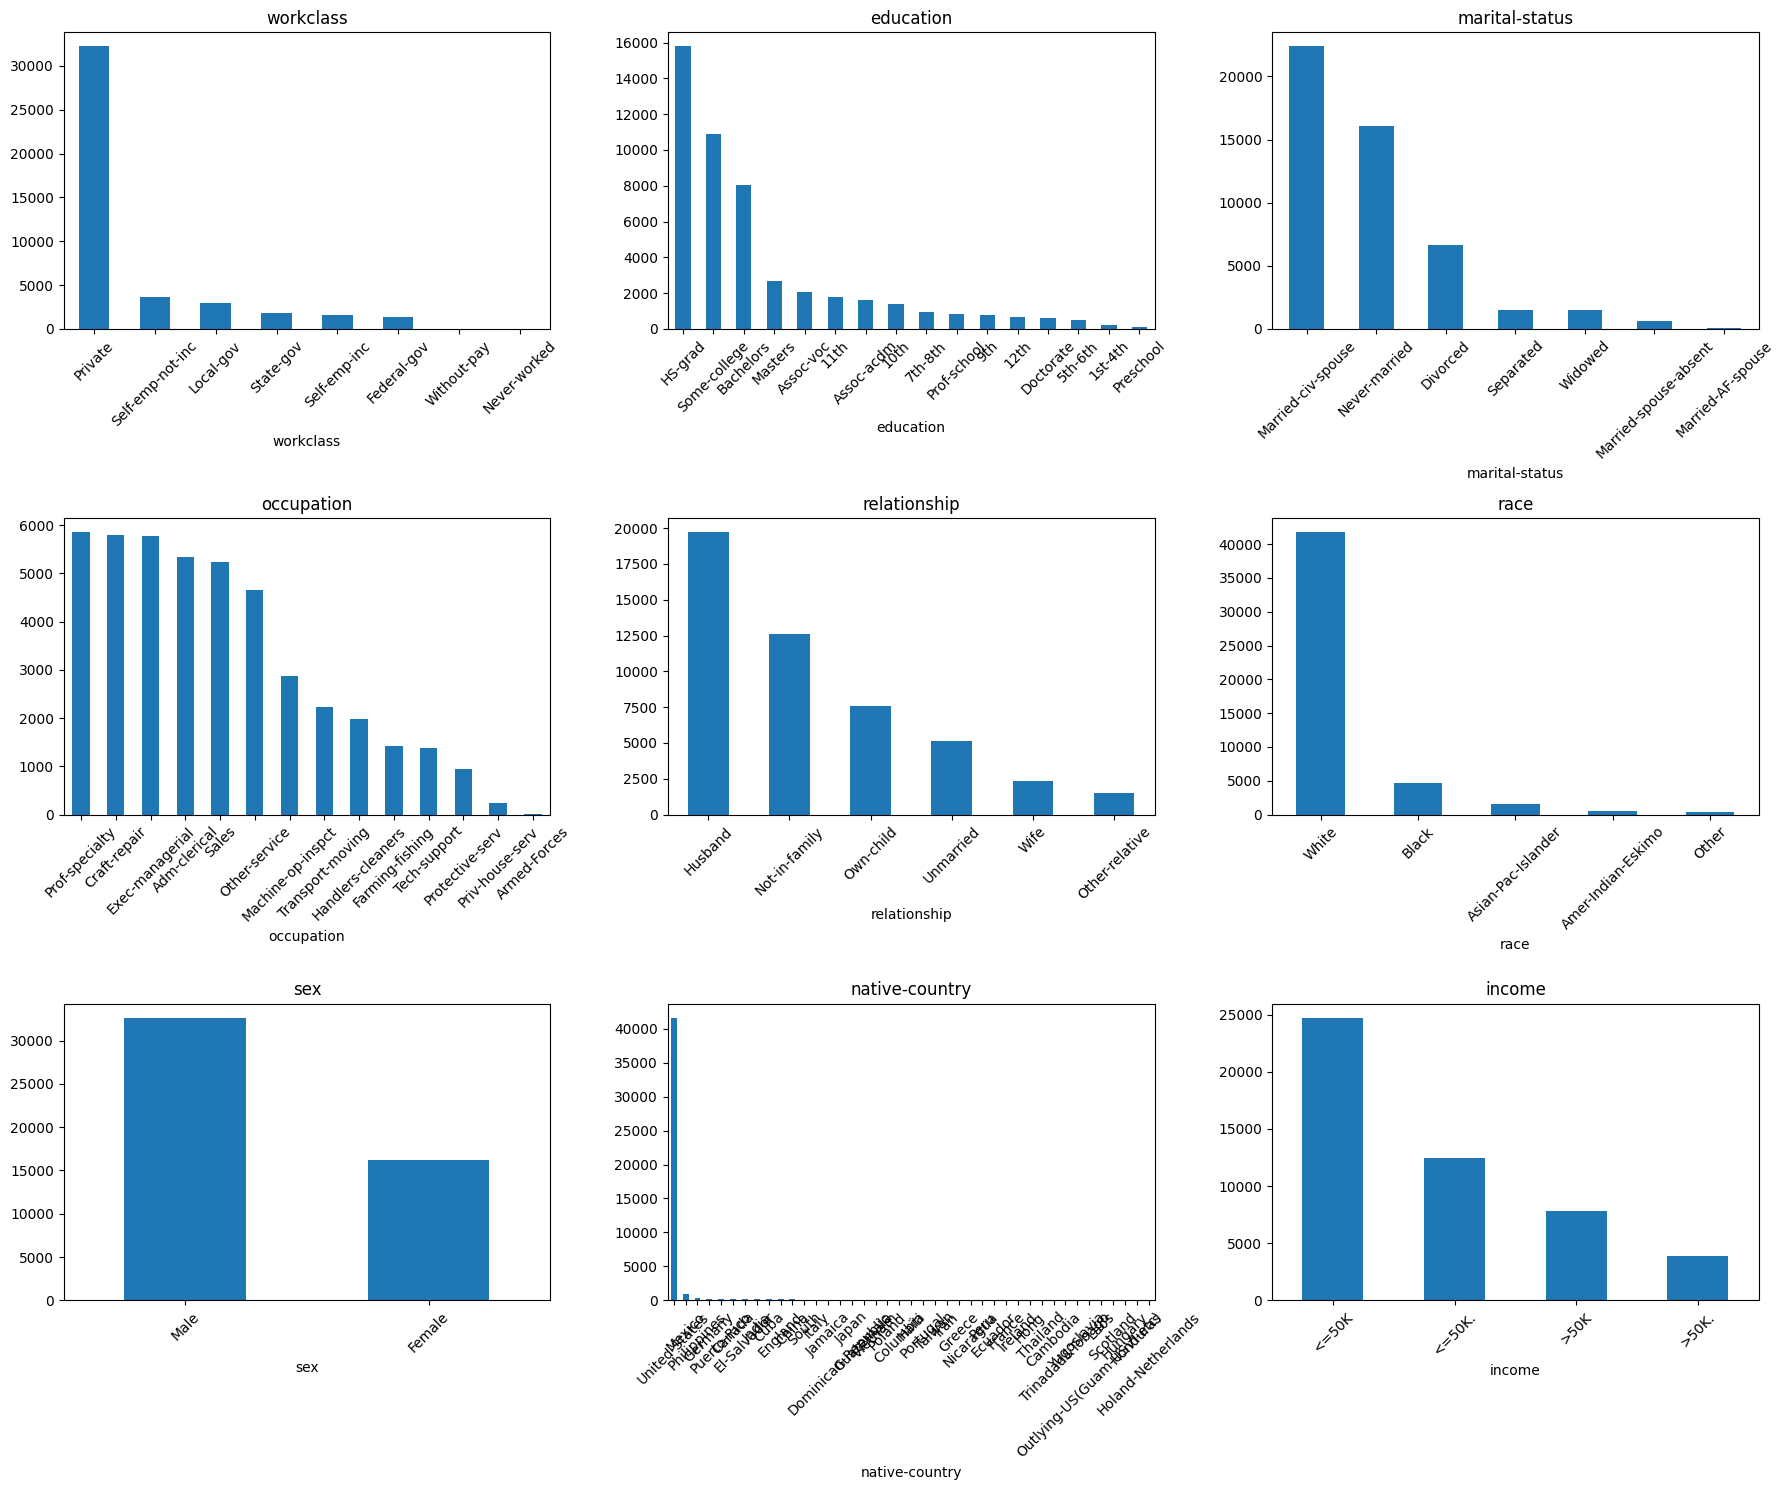

In [ ]:
plt.figure(figsize=(18,15))
for i,col in enumerate(cat_cols, 1):
  plt.subplot(3,3,i)
  df_adult[col].value_counts().plot(kind = 'bar')
  plt.title(col)
  plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [ ]:
# We use Mode 2 replace every Categorical Column

# df_adult['workclass'].fillna(df_adult['workclass'].mode() , inplace = True)
# df_adult['occupation'].fillna(df_adult['occupation'].mode() , inplace = True)
# df_adult['native-country'].fillna(df_adult['native-country'].mode() , inplace = True)

for col in ["workclass", "occupation", "native-country"]:
    df_adult[col].fillna(df_adult[col].mode()[0], inplace=True)

/tmp/ipykernel_44404/3742801993.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_adult[col].fillna(df_adult[col].mode()[0], inplace=True)


In [ ]:
# After the missing value handling of Categorical Columns
df_adult.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
# Removed the Missing values of the Categorical Columns with mode

## 2) Encode categorical variables using one-hot or label encoding

In [ ]:
df_adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [ ]:
cat_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')

In [ ]:
# Finding Unique Values of all Categorical Columns

print(df_adult['workclass'].unique(), '\n')
print(df_adult['education'].unique(), '\n')
print(df_adult['marital-status'].unique(), '\n')
print(df_adult['occupation'].unique(), '\n')
print(df_adult['relationship'].unique(), '\n')
print(df_adult['race'].unique(), '\n')
print(df_adult['sex'].unique(), '\n')
print(df_adult['native-country'].unique(), '\n')
print(df_adult['income'].unique(), '\n')

['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked'] 

['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th'] 

['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed'] 

['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' 'Protective-serv'
 'Armed-Forces' 'Priv-house-serv'] 

['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative'] 

['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other'] 

['Male' 'Female'] 

['United-States' 'Cuba' 'Jamaica' 'India' 'Mexico' 'South' 'Puerto-Rico'
 'Honduras' 'England' 'Germany' 'Iran' 'Philippines' 'Italy' 'Columbia'
 'Cambodia' 'Thailand' 'Canada' 'Ecuador

In [ ]:
# Since workclass ,occupation ,race & relationship has no natural order
# Doing 1 hot encoding on mentioned column()

df_adult = pd.get_dummies(df_adult, columns=['workclass'],dtype =int)
df_adult = pd.get_dummies(df_adult, columns=['occupation'],dtype =int)
df_adult = pd.get_dummies(df_adult, columns=['race'],dtype =int)
df_adult = pd.get_dummies(df_adult, columns=['relationship'],dtype =int)

In [ ]:
# Doing label encoding on mentioned column()
label_encoder = LabelEncoder()

df_adult['sex'] = label_encoder.fit_transform(df_adult['sex'])
df_adult['native-country'] = label_encoder.fit_transform(df_adult['native-country'])
df_adult['income'] = label_encoder.fit_transform(df_adult['income'])
df_adult['education'] = label_encoder.fit_transform(df_adult['education'])
df_adult['marital-status'] = label_encoder.fit_transform(df_adult['marital-status'])

In [ ]:
# After Encoding

df_adult.head(5)

,age,fnlwgt,education,education-num,marital-status,sex,capital-gain,capital-loss,hours-per-week,native-country,...,race_Asian-Pac-Islander,race_Black,race_Other,race_White,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
0,39.0,77516,9,13,4,1,2174,0,40.0,38,...,0,0,0,1,0,1,0,0,0,0
1,50.0,83311,9,13,2,1,0,0,13.0,38,...,0,0,0,1,1,0,0,0,0,0
2,38.0,215646,11,9,0,1,0,0,40.0,38,...,0,0,0,1,0,1,0,0,0,0
3,53.0,234721,1,7,2,1,0,0,40.0,38,...,0,1,0,0,1,0,0,0,0,0
4,28.0,338409,9,13,2,0,0,0,40.0,4,...,0,1,0,0,0,0,0,0,0,1


## 3) Detect and treat outliers using IQR or z-score

### a) Statistical Summary of Columns

In [ ]:
df_adult.describe()

,age,fnlwgt,education,education-num,marital-status,sex,capital-gain,capital-loss,hours-per-week,native-country,...,race_Asian-Pac-Islander,race_Black,race_Other,race_White,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,...,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.595164,1.896641e+05,10.288420,10.078089,2.618750,0.668482,1079.067626,87.502314,40.426170,36.506879,...,0.031100,0.095922,0.008313,0.855043,0.403669,0.257627,0.030834,0.155215,0.104930,0.047725
std,13.604587,1.056040e+05,3.874492,2.570973,1.507703,0.470764,7452.019058,403.004552,12.327157,5.896492,...,0.173591,0.294487,0.090794,0.352061,0.490638,0.437332,0.172870,0.362113,0.306467,0.213187
min,17.000000,1.228500e+04,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,1.175505e+05,9.000000,9.000000,2.000000,0.000000,0.000000,0.000000,40.000000,38.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,37.000000,1.781445e+05,11.000000,10.000000,2.000000,1.000000,0.000000,0.000000,40.000000,38.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,47.000000,2.376420e+05,12.000000,12.000000,4.000000,1.000000,0.000000,0.000000,45.000000,38.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,255.000000,1.490400e+06,15.000000,16.000000,6.000000,1.000000,99999.000000,4356.000000,250.000000,40.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### b) Removing Outliers (Plotting Boxplot of Numerical Columns)

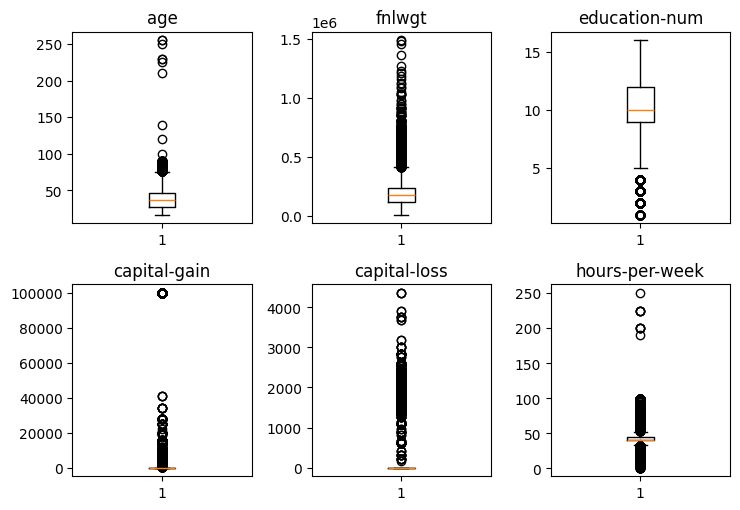

In [ ]:
# Before Outlier Handling

plt.figure(figsize=(7.5,7.5))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    plt.boxplot(df_adult[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
# =============================================
# IQR-based outlier detection pipeline
# =============================================

# These are calculated column-wise for all numerical columns.

# ---------------------------
# 1. Calculate Quartiles
# ---------------------------
Q1 = df_adult[num_cols].quantile(0.25)  # Q1 (25th percentile): value below which 25% of data lies
Q3 = df_adult[num_cols].quantile(0.75)  # Q1 (75th percentile): value below which 75% of data lies

print('Q1 of Numerical Coumns:')
print('-----------------------')
print(Q1,'\n')

print('Q3 of Numerical Coumns:')
print('-----------------------')
print(Q3,'\n')
# ---------------------------
# 2. Compute IQR
# ---------------------------
IQR = Q3 - Q1              # IQR (Interquartile Range) = spread of middle 50% of data
                           # Helps define “normal range”

print('IQR of Numerical Coumns:')
print('------------------------')
print(IQR,'\n')
# ------------

# ---------------------------
# 3. Define Limits                # These define acceptable boundaries    # Anything outside = outlier
# ---------------------------
upper_limit = Q3 + (1.5 * IQR)
lower_limit = Q1 - (1.5 * IQR)

print('upper_limit of Numerical Coumns:')
print('--------------------------------')
print(upper_limit,'\n')

print('lower_limit of Numerical Coumns:')
print('--------------------------------')
print(lower_limit,'\n')
# ---------------------------
# 4. Detect Outliers
# ---------------------------
outliers = ((df_adult[num_cols] > upper_limit) | (df_adult[num_cols] < lower_limit))  # This line checks whether values in numerical columns are outliers or not.

outliers

Q1 of Numerical Coumns:
-----------------------
age                   28.0
fnlwgt            117550.5
education-num          9.0
capital-gain           0.0
capital-loss           0.0
hours-per-week        40.0
Name: 0.25, dtype: float64 

Q3 of Numerical Coumns:
-----------------------
age                   47.0
fnlwgt            237642.0
education-num         12.0
capital-gain           0.0
capital-loss           0.0
hours-per-week        45.0
Name: 0.75, dtype: float64 

IQR of Numerical Coumns:
------------------------
age                   19.0
fnlwgt            120091.5
education-num          3.0
capital-gain           0.0
capital-loss           0.0
hours-per-week         5.0
dtype: float64 

upper_limit of Numerical Coumns:
--------------------------------
age                   75.50
fnlwgt            417779.25
education-num         16.50
capital-gain           0.00
capital-loss           0.00
hours-per-week        52.50
dtype: float64 

lower_limit of Numerical Coumns:
---------

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
0,False,False,False,True,False,False
1,False,False,False,False,False,True
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
48837,False,False,False,False,False,False
48838,False,False,False,False,False,False
48839,False,False,False,False,False,False
48840,False,False,False,True,False,False


In [ ]:
# View outlier rows
outliers_df = df_adult[outliers.any(axis=1)]

# % of outlier
outliers_percentage = len(outliers_df) * 100/ len(df_adult)
print('Percentage of outliers in the dataframe :', outliers_percentage)

print("Outliers:")
# print(outliers_df)
outliers_df

Percentage of outliers in the dataframe : 40.448794070676875
Outliers:


,age,fnlwgt,education,education-num,marital-status,sex,capital-gain,capital-loss,hours-per-week,native-country,...,race_Asian-Pac-Islander,race_Black,race_Other,race_White,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
0,39.0,77516,9,13,4,1,2174,0,40.0,38,...,0,0,0,1,0,1,0,0,0,0
1,50.0,83311,9,13,2,1,0,0,13.0,38,...,0,0,0,1,1,0,0,0,0,0
6,49.0,160187,6,5,3,0,0,0,16.0,22,...,0,1,0,0,0,1,0,0,0,0
8,31.0,45781,12,14,4,0,14084,0,50.0,38,...,0,0,0,1,0,1,0,0,0,0
9,42.0,159449,9,13,2,1,5178,0,40.0,38,...,0,0,0,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48825,64.0,136405,11,9,6,1,0,0,32.0,38,...,0,0,0,1,0,1,0,0,0,0
48827,55.0,224655,11,9,5,0,0,0,32.0,38,...,0,0,0,1,0,1,0,0,0,0
48833,31.0,440129,11,9,2,1,0,0,40.0,38,...,0,0,0,1,1,0,0,0,0,0
48840,44.0,83891,9,13,0,1,5455,0,40.0,38,...,1,0,0,0,0,0,0,1,0,0


In [ ]:
# We are removing outliers because, removing outliers is not affecting the data much (Reason : percentage of outliers is < 5%)

# option 1 : clipping.
df_adult[num_cols] = df_adult[num_cols].clip( lower_limit, upper_limit, axis = 1)

clean_df = df_adult[num_cols]
# option 2 : Remove outliers
# clean_df = df_adult[~outliers.any(axis=1)]

print("\nDataset after removing outliers:")
# print(clean_df)
clean_df


Dataset after removing outliers:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
0,39.0,77516.0,13.0,0,0,40.0
1,50.0,83311.0,13.0,0,0,32.5
2,38.0,215646.0,9.0,0,0,40.0
3,53.0,234721.0,7.0,0,0,40.0
4,28.0,338409.0,13.0,0,0,40.0
...,...,...,...,...,...,...
48837,39.0,215419.0,13.0,0,0,36.0
48838,64.0,321403.0,9.0,0,0,40.0
48839,38.0,374983.0,13.0,0,0,50.0
48840,44.0,83891.0,13.0,0,0,40.0


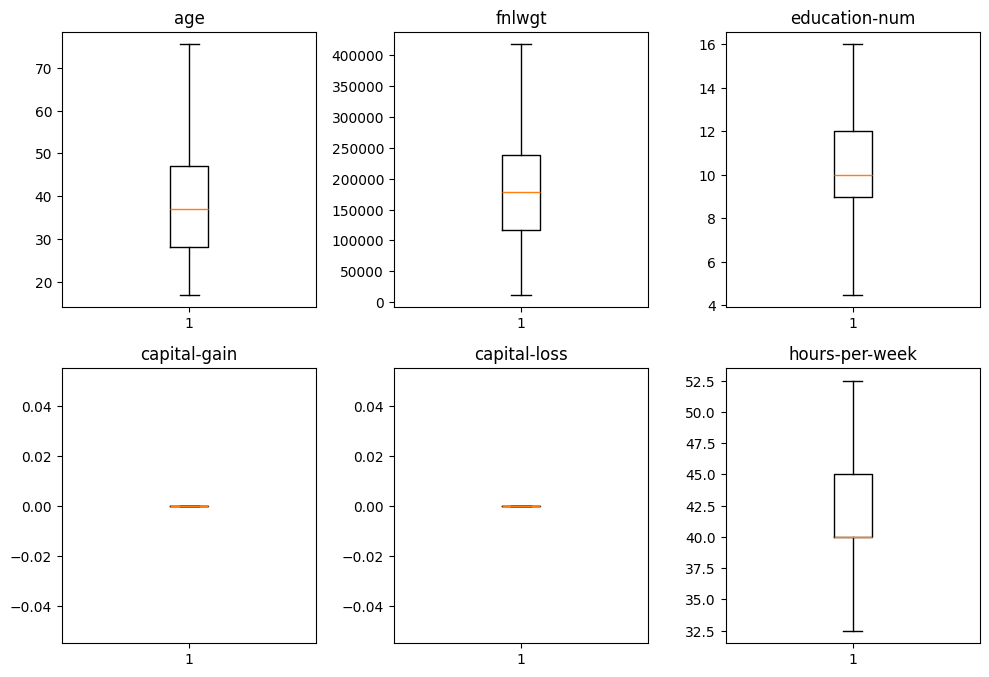

In [ ]:
# After Outlier handling

plt.figure(figsize=(10,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    plt.boxplot(clean_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## 4) Normalize or Scale numerical features


In [ ]:
# it is done on numerical values.
# it is to convert data from one scale to another
# ---------------=                         # ---------------=
# Min-Max scalar                           # Standard scalar
# ---------------=                         # ---------------=
# Scaling data into the range (0 to 1)     # Scaling into a distribution where mean and std deviation is 1
# Used when data distribution is Skewed    # Used when data distribution is Normal

In [ ]:
# Before Scaling

df_adult.head(2)

,age,fnlwgt,education,education-num,marital-status,sex,capital-gain,capital-loss,hours-per-week,native-country,...,race_Asian-Pac-Islander,race_Black,race_Other,race_White,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
0,39.0,77516.0,9,13.0,4,1,0,0,40.0,38,...,0,0,0,1,0,1,0,0,0,0
1,50.0,83311.0,9,13.0,2,1,0,0,32.5,38,...,0,0,0,1,1,0,0,0,0,0


In [ ]:
# Before Scaling

df_adult.describe()

,age,fnlwgt,education,education-num,marital-status,sex,capital-gain,capital-loss,hours-per-week,native-country,...,race_Asian-Pac-Islander,race_Black,race_Other,race_White,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.0,48842.0,48842.000000,48842.000000,...,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.531387,186770.707163,10.288420,10.122088,2.618750,0.668482,0.0,0.0,41.129683,36.506879,...,0.031100,0.095922,0.008313,0.855043,0.403669,0.257627,0.030834,0.155215,0.104930,0.047725
std,13.271160,95328.614282,3.874492,2.456895,1.507703,0.470764,0.0,0.0,6.033548,5.896492,...,0.173591,0.294487,0.090794,0.352061,0.490638,0.437332,0.172870,0.362113,0.306467,0.213187
min,17.000000,12285.000000,0.000000,4.500000,0.000000,0.000000,0.0,0.0,32.500000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,117550.500000,9.000000,9.000000,2.000000,0.000000,0.0,0.0,40.000000,38.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,37.000000,178144.500000,11.000000,10.000000,2.000000,1.000000,0.0,0.0,40.000000,38.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,47.000000,237642.000000,12.000000,12.000000,4.000000,1.000000,0.0,0.0,45.000000,38.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,75.500000,417779.250000,15.000000,16.000000,6.000000,1.000000,0.0,0.0,52.500000,40.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


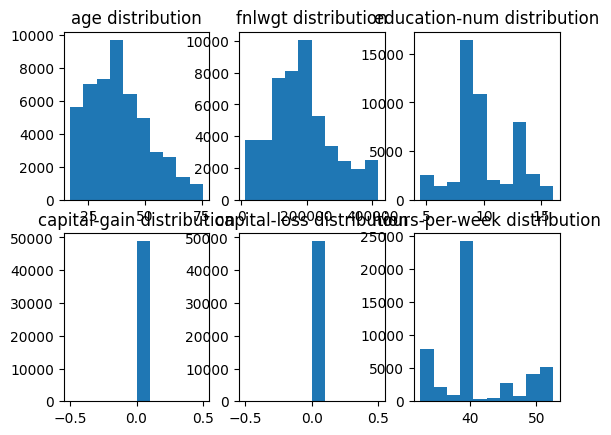

In [ ]:
for i,col in enumerate(num_cols, 1):
  plt.subplot(2,3,i)
  plt.hist(df_adult[col])            # age distribution income distribution  kaanan
  plt.title(col+ " distribution")

plt.show()


In [ ]:
# Detecting Skewness
df_adult[num_cols].skew()

,0
age,0.530399
fnlwgt,0.555106
education-num,-0.035567
capital-gain,0.000000
capital-loss,0.000000
hours-per-week,0.480552


In [ ]:
# ----------------------------
# Interpretation
# ----------------------------
# 0 → normal distribution
# > 1 → highly right-skewed
# < -1 → highly left-skewed

# ---------------------------------------------------------
#    Interpretation of Census Dataset Histograms
# ---------------------------------------------------------
#               Typical observations:
# ---------------------------------------------------------
#     Column	               Distribution Insight
# ----------------------------------------------------------
#      age	                Slightly right-skewed
#    fnlwgt	                  Highly skewed
# education-num	          Discrete distribution
# capital-gain	    Extremely right-skewed with many zeros
# capital-loss	             Mostly zeros
# hours-per-week        	Peak around 40 hours
# ---------------------------------------------------------

In [ ]:
# Feature Scaling
# Scaling is important before PCA and clustering.

# Using StandardScaler:
standard_scaler = StandardScaler()
df_adult[['capital-gain','capital-loss', 'age','fnlwgt', 'education-num', 'hours-per-week']] = standard_scaler.fit_transform(df_adult[['capital-gain','capital-loss', 'age','fnlwgt', 'education-num', 'hours-per-week']])
scaled_data = df_adult[['capital-gain','capital-loss', 'age','fnlwgt', 'education-num', 'hours-per-week']]

In [ ]:
# After Scaling
df_adult.head()

,age,fnlwgt,education,education-num,marital-status,sex,capital-gain,capital-loss,hours-per-week,native-country,...,race_Asian-Pac-Islander,race_Black,race_Other,race_White,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
0,0.035311,-1.146097,9,1.171374,4,1,0.0,0.0,-0.187236,38,...,0,0,0,1,0,1,0,0,0,0
1,0.864184,-1.085307,9,1.171374,2,1,0.0,0.0,-1.430298,38,...,0,0,0,1,1,0,0,0,0,0
2,-0.040041,0.302906,11,-0.456714,0,1,0.0,0.0,-0.187236,38,...,0,0,0,1,0,1,0,0,0,0
3,1.090241,0.503005,1,-1.270758,2,1,0.0,0.0,-0.187236,38,...,0,1,0,0,1,0,0,0,0,0
4,-0.793562,1.590706,9,1.171374,2,0,0.0,0.0,-0.187236,4,...,0,1,0,0,0,0,0,0,0,1


In [ ]:
# After Scaling
df_adult.describe()

,age,fnlwgt,education,education-num,marital-status,sex,capital-gain,capital-loss,hours-per-week,native-country,...,race_Asian-Pac-Islander,race_Black,race_Other,race_White,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
count,4.884200e+04,4.884200e+04,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.0,48842.0,4.884200e+04,48842.000000,...,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,-1.786468e-16,1.774829e-17,10.288420,-3.207786e-16,2.618750,0.668482,0.0,0.0,4.042828e-16,36.506879,...,0.031100,0.095922,0.008313,0.855043,0.403669,0.257627,0.030834,0.155215,0.104930,0.047725
std,1.000010e+00,1.000010e+00,3.874492,1.000010e+00,1.507703,0.470764,0.0,0.0,1.000010e+00,5.896492,...,0.173591,0.294487,0.090794,0.352061,0.490638,0.437332,0.172870,0.362113,0.306467,0.213187
min,-1.622436e+00,-1.830379e+00,0.000000,-2.288313e+00,0.000000,0.000000,0.0,0.0,-1.430298e+00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.935625e-01,-7.261295e-01,9.000000,-4.567143e-01,2.000000,0.000000,0.0,0.0,-1.872356e-01,38.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-1.153933e-01,-9.049010e-02,11.000000,-4.969232e-02,2.000000,1.000000,0.0,0.0,-1.872356e-01,38.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.381281e-01,5.336468e-01,12.000000,7.643517e-01,4.000000,1.000000,0.0,0.0,6.414727e-01,38.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,2.785664e+00,2.423311e+00,15.000000,2.392440e+00,6.000000,1.000000,0.0,0.0,1.884535e+00,40.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# from std scalr ,   become std = 1 ,and mean = 0
# mean is very close to 0 , some gets mean =0 ,

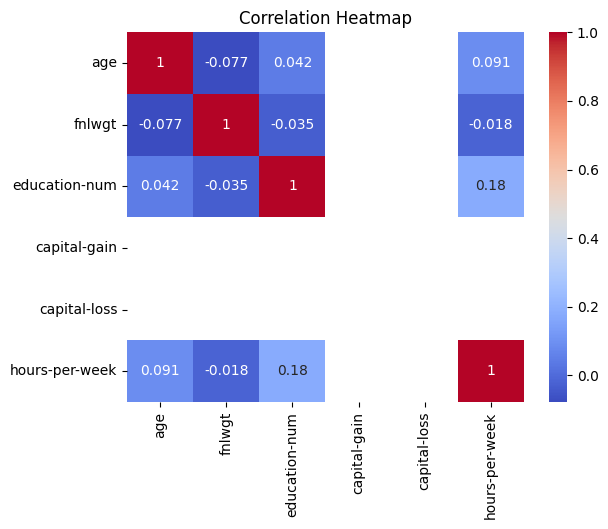

In [ ]:
# Correlation after scaling

corr_matrix = df_adult[num_cols].corr(method= 'pearson')
corr_matrix


# ploting a heat map to visualize the correlation
sns.heatmap(corr_matrix, annot = True , cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# II) Exploratory Analysis

## 1) Visualize Feature Distributions

### a) Numerical Columns

In [ ]:
num_cols = ['age',
            'fnlwgt',
            'education-num',
            'capital-gain',
            'capital-loss',
            'hours-per-week']

#### i) Histogram Distribution

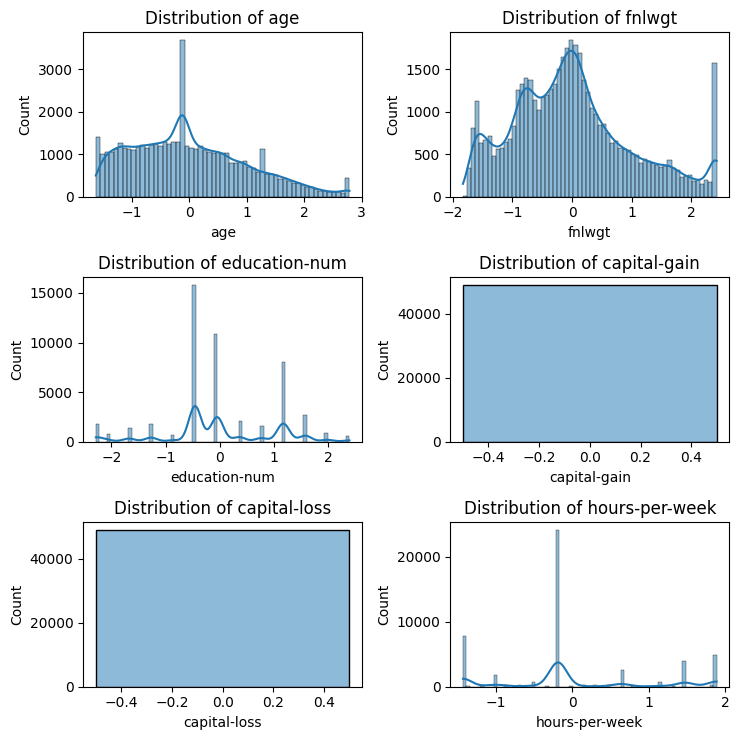

In [ ]:
plt.figure(figsize=(7.5,7.5))

for i,col in enumerate(num_cols,1):

    plt.subplot(3,2,i)

    sns.histplot(df_adult[col], kde=True)

    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [ ]:
# ==========================
# Insights from Histograms
# ==========================
# age
# ---
# Slightly right-skewed
# Most people between 20–50

# fnlwgt
# -------
# Highly spread
# Not normally distributed

# capital-gain / capital-loss
# ---------------------------
# Highly skewed
# Many zero values
# Presence of outliers

# hours-per-week
# ---------------
# Most people work 40 hours/week

#### ii) Boxplots for Outlier Detection

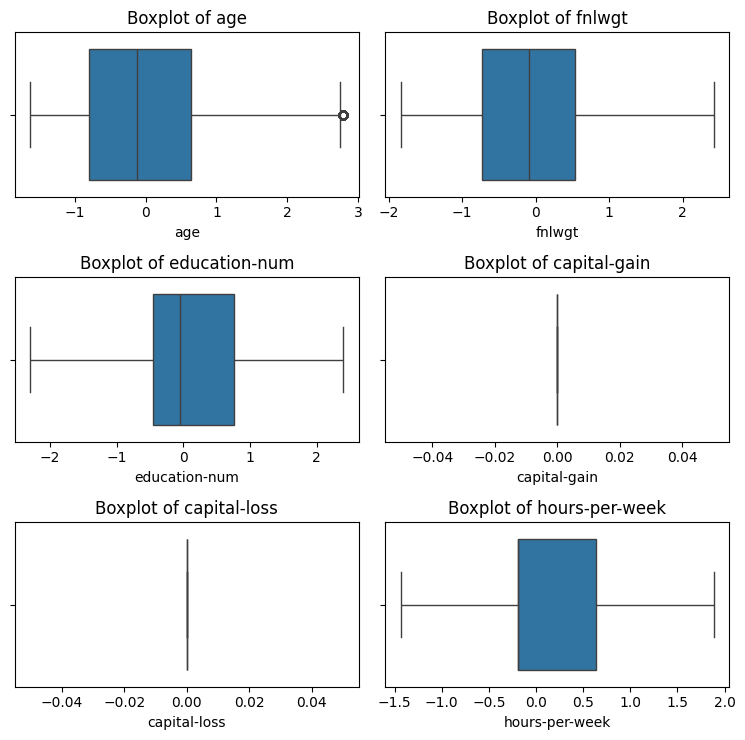

In [ ]:
plt.figure(figsize=(7.5,7.5))

for i,col in enumerate(num_cols,1):

    plt.subplot(3,2,i)

    sns.boxplot(x=df_adult[col])

    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [ ]:
# ==========================
# Insights from Boxplots
# ==========================
# Outliers may exist in:
#   capital-gain
#   capital-loss
#   hours-per-week
#   age
#------------------------------
# These outliers influence clustering because clustering algorithms use distance metrics.

### b) Categorical Columns


In [ ]:
cat_cols = ['workclass',
            'education',
            'marital-status',
            'occupation',
            'relationship',
            'race',
            'sex',
            'native-country',
            'income']

#### i) Histogram Distribution

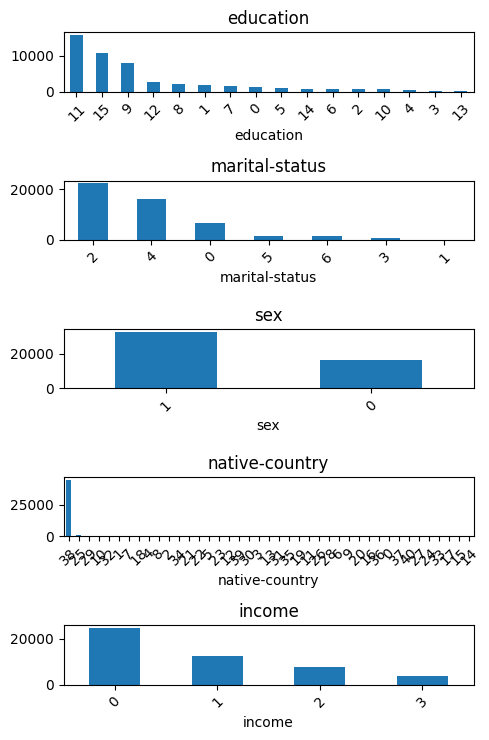

In [ ]:
plt.figure(figsize=(5,7.5))

# Redefine cat_cols to include only existing label-encoded categorical columns
# 'workclass', 'occupation', 'relationship', 'race' were one-hot encoded and no longer exist as single columns.
# 'education', 'marital-status', 'sex', 'native-country', and 'income' were label encoded and still exist.
current_cat_cols = ['education', 'marital-status', 'sex', 'native-country', 'income']

for i,col in enumerate(current_cat_cols,1):

    plt.subplot(len(current_cat_cols),1,i)

    df_adult[col].value_counts().plot(kind='bar')

    plt.title(col)

    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# ===================================
# Insights from Categorical Variables
# ===================================
# workclass
# ---------
# Majority belong to Private sector

# education
# ---------
# HS-grad and Some-college dominate

# marital-status
# --------------
# Married-civ-spouse highly common

# occupation
# ----------
# Diverse job distribution

# native-country
# --------------
# Mostly United States
#======================================

## 2) Analyze correlations between Variables

In [ ]:
# Correlation helps understand relationships between numerical variables.

corr = df_adult[num_cols].corr()

corr

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.077034,0.041776,NaN,NaN,0.090682
fnlwgt,-0.077034,1.000000,-0.034922,NaN,NaN,-0.018393
education-num,0.041776,-0.034922,1.000000,NaN,NaN,0.176989
capital-gain,NaN,NaN,NaN,NaN,NaN,NaN
capital-loss,NaN,NaN,NaN,NaN,NaN,NaN
hours-per-week,0.090682,-0.018393,0.176989,NaN,NaN,1.000000


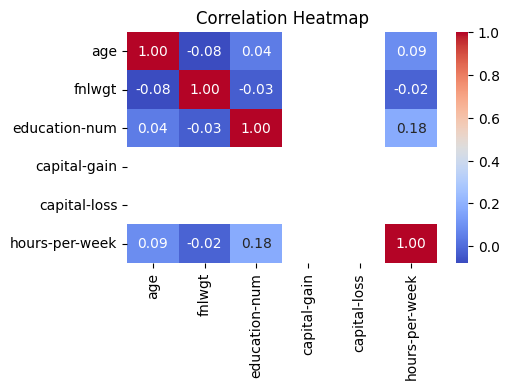

In [ ]:
plt.figure(figsize=(5,3))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
#============================
# Insights from Correlation
#============================
# Possible observations:
#----------------------------
# education-num may correlate with capital-gain
# age may correlate with hours-per-week
# capital-gain and capital-loss usually weakly correlated
#=========================================================

## 3) Use dimensionality reduction (PCA Or t-SNE) to visualize high-dimensional data

### a) Feature Scaling

In [ ]:
# Scaling is important before PCA and clustering.

# Using StandardScaler:

# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(df_adult)

# standard_scaler = StandardScaler()
# df_adult[['capital-gain','capital-loss']] = standard_scaler.fit_transform(df_adult[['capital-gain','capital-loss']])

### b1) PCA (Principal Component Analysis)

In [ ]:
# -----------
# Purpose:
# -----------
# Reduce dimensionality
# Visualize high-dimensional data
# ----------------------------------

In [ ]:
# PCA Transformation

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)


In [ ]:
# Create PCA DataFrame

pca_df = pd.DataFrame(pca_data,
                      columns=['PC1','PC2'])

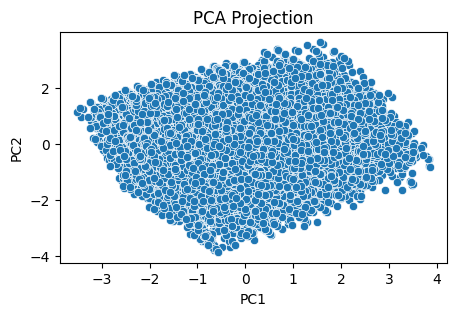

In [ ]:
# PCA Scatter Plot

plt.figure(figsize=(5,3))

sns.scatterplot(x='PC1',
                y='PC2',
                data=pca_df)

plt.title("PCA Projection")

plt.show()

In [ ]:
# =============================
# PCA Insights
# =============================
# PCA helps:
# ------------
#  visualize hidden patterns
#  understand data spread
#  reduce noise
#  improve clustering efficiency
# =============================

In [ ]:
#===============================
# Final EDA Insights (Expected)
#===============================

# From exploratory analysis, we may discover:

#----------------
# Group patterns:
#----------------
# # Highly educated professionals
# # Low-income labor groups
# # Retired/non-working populations
# # Long working-hour professionals
#----------------------
# Data characteristics:
#----------------------
# # Skewed income-related variables
# # Strong dominance of certain categories
# # Significant outliers
# # Mixed demographic distributions

#=======================================
# # Importance of EDA Before Clustering
#=======================================
# EDA helps:
## choose scaling techniques
## detect outliers
## understand feature importance
## decide clustering strategy
## improve cluster interpretability

### b2) t-SNE (t-Distributed Stochastic Neighbor Embedding)

In [ ]:
# Take random sample
X = scaled_data
sample_df = X.sample(n=2000, random_state=42)

# Scale sampled data
# X_sample is already scaled, no need for scaler.fit_transform here
X_sample = sample_df

# Apply t-SNE (t-SNE reduces high-dimensional data into 2 dimensions.)
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

X_tsne = tsne.fit_transform(X_sample)

In [ ]:
# Create t-SNE DataFrame

tsne_df = pd.DataFrame({
    'TSNE1': X_tsne[:, 0],
    'TSNE2': X_tsne[:, 1]
})

print(tsne_df.head())

       TSNE1      TSNE2
0 -39.231068  -0.531579
1 -54.439056  10.596315
2 -29.205881 -16.785517
3 -45.659481  12.048664
4  36.685287  -4.112105


# III) Clustering

Apply clustering algorithms:

## 1) KMeans (use elbow method silhouette score to choose k)

In [ ]:
# -----
# Goal:
# -----
# Use Unsupervised learning techniques to discover hidden socioeconomic groups.

# -----------
# Algorithms:
# -----------
# KMeans Clustering
# Agglomerative Clustering

#--------------------------------------
#  Use Preprocessed & Scaled Dataset
# -------------------------------------
# Assume:
# ----------
# missing values handled
# categorical variables encoded
# outliers treated
# scaling completed
# ---------------------------------------

In [ ]:
X = scaled_data

### a) Elbow Method for Optimal K

In [ ]:
# The elbow method helps choose the optimal number of clusters.

#### i) Elbow Method Code

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# find the optimal number of clusters (K) for K-Means clustering using the Elbow Method.
wcss = []

K = range(2,11)

for k in K:

    kmeans = KMeans(n_clusters=k,random_state=42, n_init='auto')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

In [ ]:
wcss

[156655.99851012754,
 134062.5907533171,
 108347.85275364613,
 94958.6956400617,
 85335.39109791462,
 80194.00787659413,
 75949.58227381033,
 70771.50792629123,
 66395.12399179282]

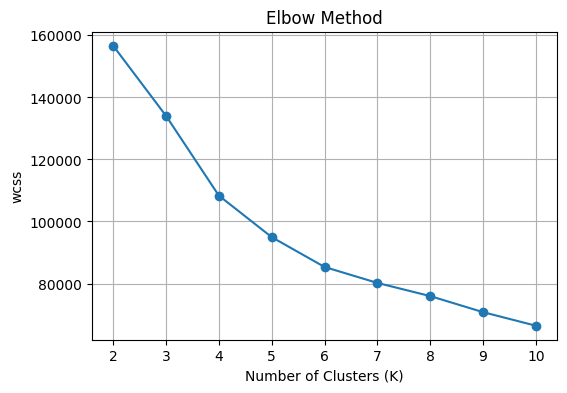

In [ ]:
# Elbow pl0t(k vs wcss)

plt.figure(figsize=(6,4))

plt.plot(K,wcss,marker='o')

plt.xlabel("Number of Clusters (K)")

plt.ylabel("wcss")

plt.title("Elbow Method")
plt.grid()
plt.show()

In [ ]:
# ====================================
# Interpretation
# ====================================
# Choose K where:
# ----------------
# curve bends sharply (“elbow point”)
# wcss reduction slows

# Example:
# optimal K may be 4 or 5
# =====================================

#### ii) Silhouette Score

In [ ]:
# --------------------------------------------
# Silhouette score measures cluster quality.
# --------------------------------------------
# Range:
# -------
# close to +1 → good clustering
# close to 0 → overlapping clusters
# close to -1 → poor clustering

In [ ]:
for k in range(2,11):

    kmeans = KMeans(n_clusters=k,
                    random_state=42,
                    n_init='auto') # Added n_init='auto' to suppress future warnings.

    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)

    print(f"K = {k}, Silhouette Score = {score}")

K = 2, Silhouette Score = 0.19320270076132054
K = 3, Silhouette Score = 0.1900677808512532
K = 4, Silhouette Score = 0.2353515879613083
K = 5, Silhouette Score = 0.24182851737453545
K = 6, Silhouette Score = 0.2515877215721679
K = 7, Silhouette Score = 0.23810789696499882
K = 8, Silhouette Score = 0.20575717308065986
K = 9, Silhouette Score = 0.20968013100034943
K = 10, Silhouette Score = 0.21713345210818305


In [ ]:
# =============================
# Interpretation
# =============================
# Choose K with:
# ---------------
# highest silhouette score
# meaningful cluster separation
# =============================

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Final KMeans Clustering (Using K = 4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')

kmeans_labels = kmeans.fit_predict(X)

In [ ]:
# Add Cluster Labels
df_adult['Clusters'] = kmeans_labels

In [ ]:
df_adult['Clusters']

,Clusters
0,0
1,1
2,0
3,1
4,2
...,...
48837,0
48838,1
48839,2
48840,0


#### iii) Cluster Visualization

In [ ]:
# Reduce dimensions to 2D for plotting.

In [ ]:
# PCA Transformation

pca = PCA(n_components=2)

pca_data = pca.fit_transform(X)

In [ ]:
# PCA DataFrame
pca_df = pd.DataFrame(pca_data,
                      columns=['PC1','PC2'])

pca_df['Clusters'] = kmeans_labels

#### iv) KMeans Cluster Visualization

##### 1) Using PCA

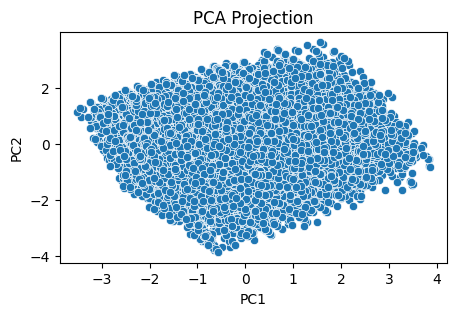

In [ ]:
# PCA Scatter Plot

plt.figure(figsize=(5,3))

sns.scatterplot(x='PC1',
                y='PC2',
                data=pca_df)

plt.title("PCA Projection")

plt.show()

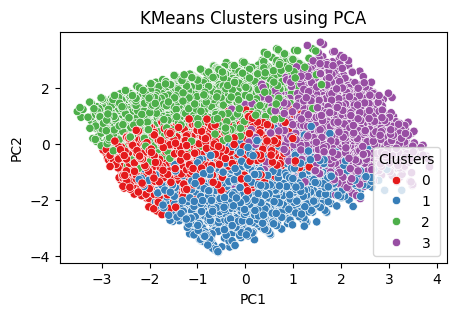

In [ ]:
# KMeans Cluster Visualization using PCA
plt.figure(figsize=(5,3))

sns.scatterplot(x='PC1',
                y='PC2',
                hue='Clusters',
                palette='Set1',
                data=pca_df)

plt.title("KMeans Clusters using PCA")

plt.show()

##### 2) Using t-sne

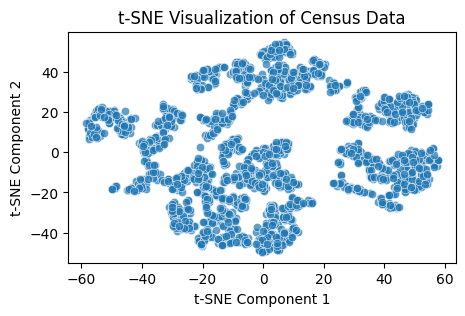

In [ ]:
plt.figure(figsize=(5, 3))

sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    data=tsne_df,
    alpha=0.7
)

plt.title('t-SNE Visualization of Census Data')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init='auto'
)

# Perform KMeans clustering on the sampled data (X_sample) to match the size of tsne_df
clusters = kmeans.fit_predict(X_sample)

tsne_df['Clusters'] = clusters

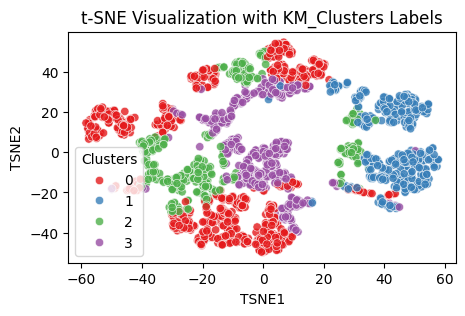

In [ ]:
plt.figure(figsize=(5,3))

sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    hue='Clusters',
    palette='Set1',
    data=tsne_df,
    alpha=0.8
)

plt.title('t-SNE Visualization with KM_Clusters Labels')

plt.show()

## 2) Agglomerative Clustering

In [ ]:
# Hierarchical clustering approach.

In [ ]:
X = scaled_data

In [ ]:
from sklearn.decomposition import PCA

# Ensure pca_data is defined for Agglomerative Clustering if this cell is run independently
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X) # X is scaled_data from earlier cells

X_sample = pca_data[:5000]  # adjust size
agglo_labels = AgglomerativeClustering(n_clusters=4).fit_predict(X_sample)

# agglo = AgglomerativeClustering(n_clusters=4)
# agglo_labels = agglo.fit_predict(X)

In [ ]:
# Agglomerative Cluster Visualization
# Create a new pca_df for the sampled data used in agglomerative clustering
pca_df_sampled = pd.DataFrame(pca_data[:5000], columns=['PC1', 'PC2'])
pca_df_sampled['Agglo_Cluster'] = agglo_labels

#  pca_df['Agglo_Cluster'] = agglo_labels

### i) Agglomerative Cluster Visualization

##### 1) Using PCA

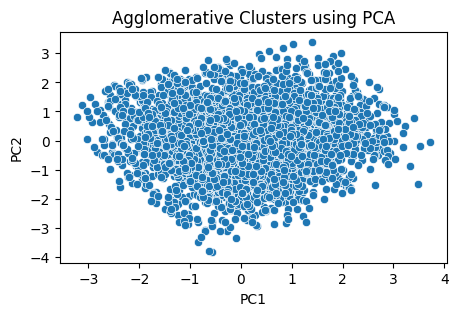

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,3))

sns.scatterplot(x='PC1',
                y='PC2',
                data=pca_df_sampled) # Use the new sampled dataframe

plt.title("Agglomerative Clusters using PCA")

plt.show()

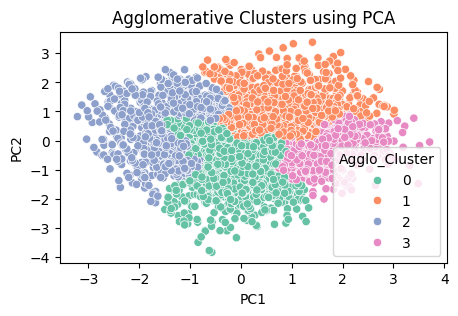

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,3))

sns.scatterplot(x='PC1',
                y='PC2',
                hue='Agglo_Cluster',
                palette='Set2',
                data=pca_df_sampled) # Use the new sampled dataframe

plt.title("Agglomerative Clusters using PCA")

plt.show()

##### 2) Using t-sne

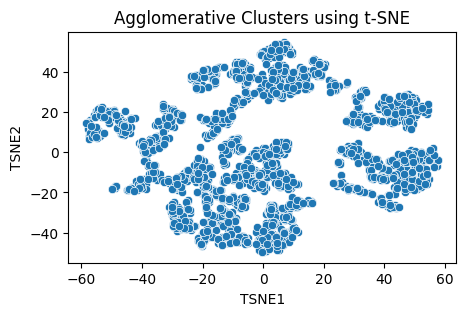

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering

plt.figure(figsize=(5,3))

# Perform Agglomerative Clustering on the t-SNE transformed data (X_tsne)
# X_tsne has 2000 samples, matching tsne_df
agglo = AgglomerativeClustering(n_clusters=4) # Assuming 4 clusters based on previous KMeans selection
agglo_labels_tsne = agglo.fit_predict(X_tsne)

# Add the agglomerative cluster labels to tsne_df
tsne_df['Agglo_Cluster'] = agglo_labels_tsne

sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    data=tsne_df
)

plt.title("Agglomerative Clusters using t-SNE")

plt.show()

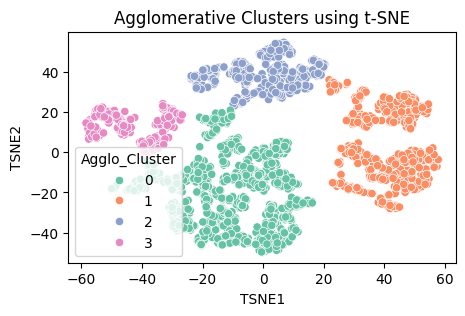

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering

plt.figure(figsize=(5,3))

# Perform Agglomerative Clustering on the t-SNE transformed data (X_tsne)
# X_tsne has 2000 samples, matching tsne_df
agglo = AgglomerativeClustering(n_clusters=4) # Assuming 4 clusters based on previous KMeans selection
agglo_labels_tsne = agglo.fit_predict(X_tsne)

# Add the agglomerative cluster labels to tsne_df
tsne_df['Agglo_Cluster'] = agglo_labels_tsne

sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    hue='Agglo_Cluster',
    palette='Set2',
    data=tsne_df
)

plt.title("Agglomerative Clusters using t-SNE")

plt.show()

## 3)  Visualize clusters (20 plots With color-coded cluster labels)

In [ ]:
# =========================================================
# GENERAL PLOT SETTINGS
# =========================================================
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (5, 3)

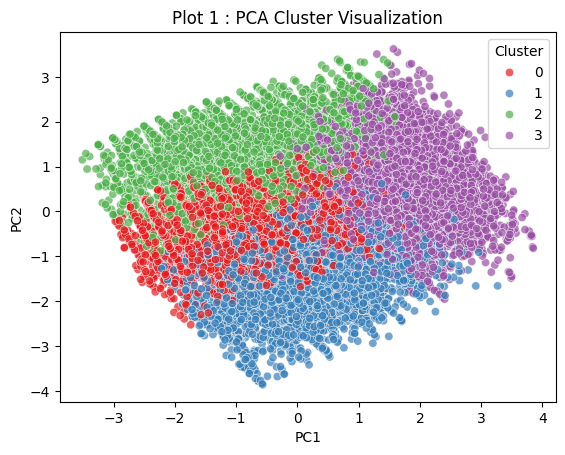

In [ ]:
# =========================================================
# PLOT 1 : PCA CLUSTER VISUALIZATION
# =========================================================
plt.figure()
sns.scatterplot(x='PC1',y='PC2',hue='Cluster',palette='Set1',data=pca_df.assign(Cluster=kmeans_labels),alpha=0.7
)
plt.title('Plot 1 : PCA Cluster Visualization')
plt.show()

In [ ]:
# Removed: The t-SNE cluster visualization is handled in the 'CREATE 20 CLUSTER VISUALIZATIONS' section (cell uozwEKiPFs3o) to avoid redundancy and fix a NameError.

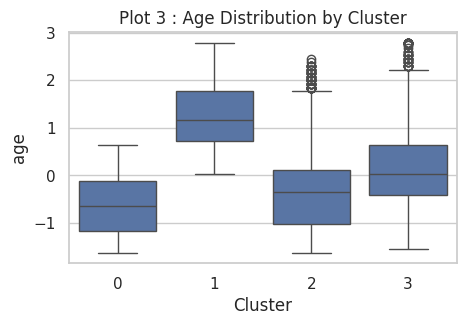

In [ ]:
plt.figure()
sns.boxplot(x='Cluster',y='age',data=df_adult.assign(Cluster=kmeans_labels))
plt.title('Plot 3 : Age Distribution by Cluster')
plt.show()

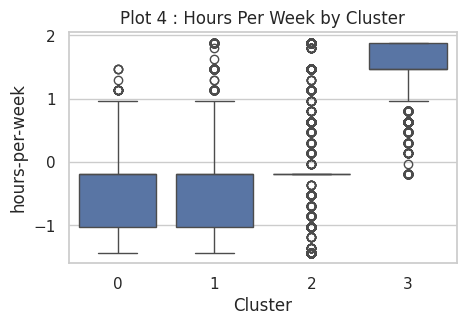

In [ ]:
# =========================================================
# PLOT 4 : HOURS PER WEEK BY CLUSTER
# =========================================================
plt.figure()
sns.boxplot(x='Cluster',y='hours-per-week',data=df_adult.assign(Cluster=kmeans_labels))
plt.title('Plot 4 : Hours Per Week by Cluster')
plt.show()

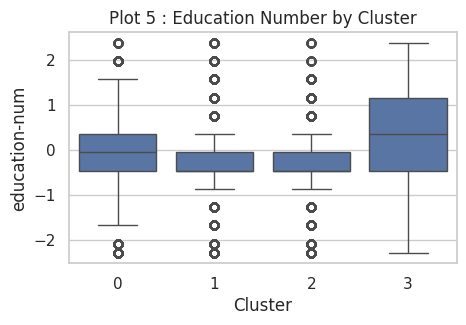

In [ ]:
# =========================================================
# PLOT 5 : EDUCATION NUM BY CLUSTER
# =========================================================
plt.figure()
sns.boxplot(x='Cluster',y='education-num',data=df_adult.assign(Cluster=kmeans_labels))
plt.title('Plot 5 : Education Number by Cluster')
plt.show()

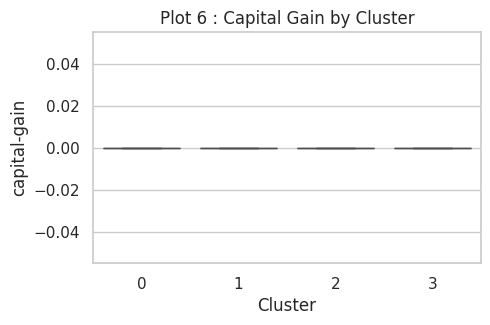

In [ ]:
# =========================================================
# PLOT 6 : CAPITAL GAIN BY CLUSTER
# =========================================================
plt.figure()
sns.boxplot(x='Cluster',y='capital-gain',data=df_adult.assign(Cluster=kmeans_labels))
plt.title('Plot 6 : Capital Gain by Cluster')
plt.show()

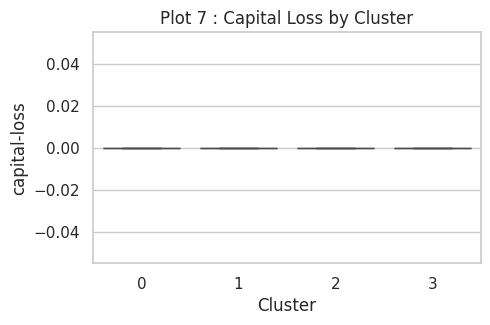

In [ ]:
# =========================================================
# PLOT 7 : CAPITAL LOSS BY CLUSTER
# =========================================================
plt.figure()
sns.boxplot(x='Cluster',y='capital-loss',data=df_adult.assign(Cluster=kmeans_labels))
plt.title('Plot 7 : Capital Loss by Cluster')
plt.show()

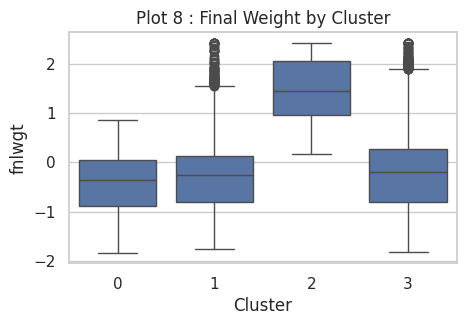

In [ ]:
# =========================================================
# PLOT 8 : FINAL WEIGHT BY CLUSTER
# =========================================================
plt.figure()
sns.boxplot(x='Cluster',y='fnlwgt',data=df_adult.assign(Cluster=kmeans_labels))
plt.title('Plot 8 : Final Weight by Cluster')
plt.show()

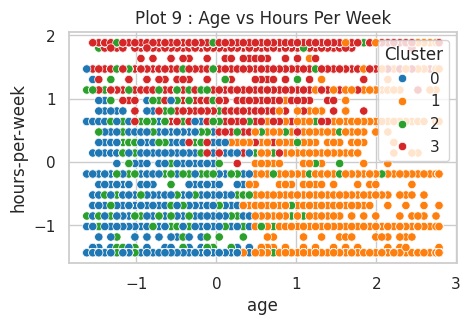

In [ ]:
# =========================================================
# PLOT 9 : AGE VS HOURS PER WEEK
# =========================================================
plt.figure()
sns.scatterplot(x='age',y='hours-per-week',hue='Cluster',palette='tab10',data=df_adult.assign(Cluster=kmeans_labels)
)
plt.title('Plot 9 : Age vs Hours Per Week')
plt.show()

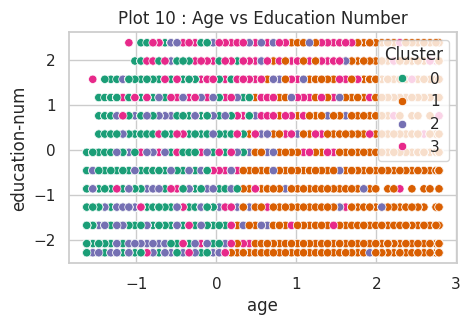

In [ ]:
plt.figure()
sns.scatterplot(x='age',y='education-num',hue='Cluster',palette='Dark2',data=df_adult.assign(Cluster=kmeans_labels)
)
plt.title('Plot 10 : Age vs Education Number')
plt.show()

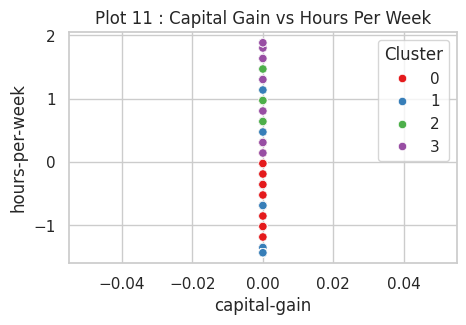

In [ ]:
# =========================================================
# PLOT 11 : CAPITAL GAIN VS HOURS PER WEEK
# =========================================================
plt.figure()
sns.scatterplot(x='capital-gain',y='hours-per-week',hue='Cluster',palette='Set1',data=df_adult.assign(Cluster=kmeans_labels)
)
plt.title('Plot 11 : Capital Gain vs Hours Per Week')
plt.show()

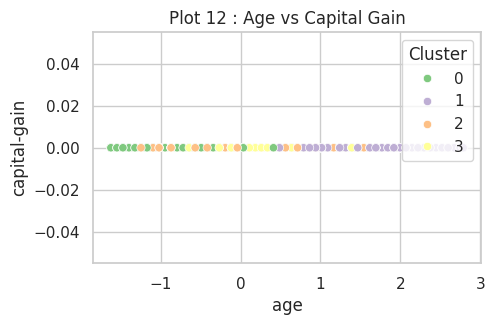

In [ ]:
# =========================================================
# PLOT 12 : AGE VS CAPITAL GAIN
# =========================================================
plt.figure()
sns.scatterplot(x='age',y='capital-gain',hue='Cluster',palette='Accent',data=df_adult.assign(Cluster=kmeans_labels)
)
plt.title('Plot 12 : Age vs Capital Gain')
plt.show()

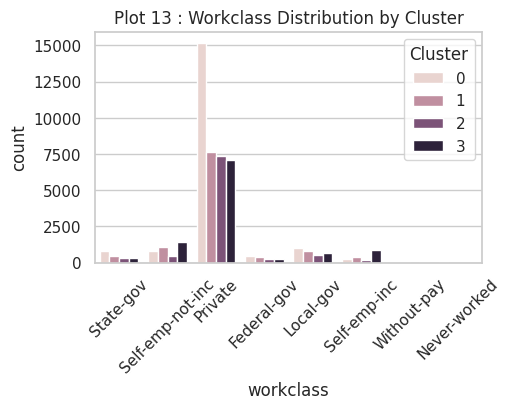

In [ ]:
# =========================================================
# PLOT 13 : WORKCLASS DISTRIBUTION
# =========================================================
plt.figure(figsize=(5,3))
sns.countplot(x='workclass',hue='Cluster',data=cluster_df
)
plt.xticks(rotation=45)
plt.title('Plot 13 : Workclass Distribution by Cluster')
plt.show()

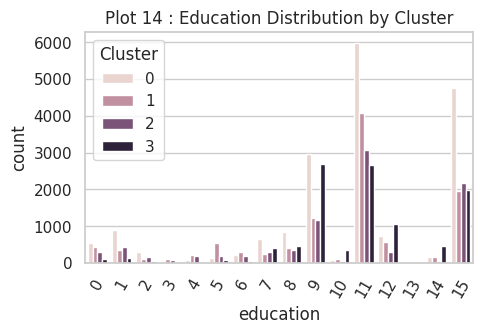

In [ ]:
# ========================================================
# PLOT 14 : EDUCATION DISTRIBUTION
# ========================================================
plt.figure(figsize=(5,3))
sns.countplot(x='education',hue='Cluster',data=cluster_df
)
plt.xticks(rotation=60)
plt.title('Plot 14 : Education Distribution by Cluster')
plt.show()

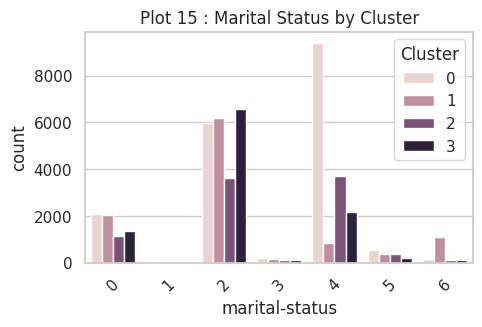

In [ ]:
# =========================================================
# PLOT 15 : MARITAL STATUS DISTRIBUTION
# =========================================================
plt.figure(figsize=(5,3))
sns.countplot(x='marital-status',hue='Cluster',data=cluster_df
)
plt.xticks(rotation=45)
plt.title('Plot 15 : Marital Status by Cluster')
plt.show()

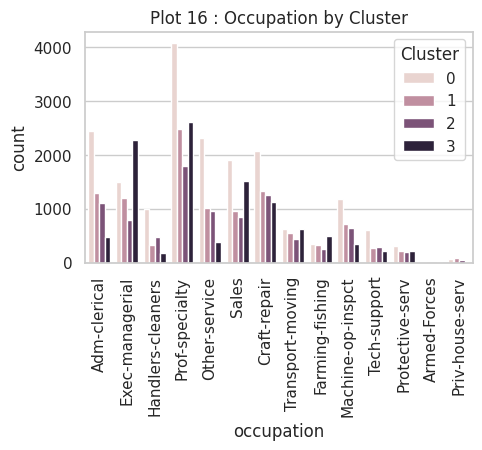

In [ ]:
# =========================================================
# PLOT 16 : OCCUPATION DISTRIBUTION
# =========================================================
plt.figure(figsize=(5,3))
sns.countplot(x='occupation',hue='Cluster',data=cluster_df)
plt.xticks(rotation=90)
plt.title('Plot 16 : Occupation by Cluster')
plt.show()

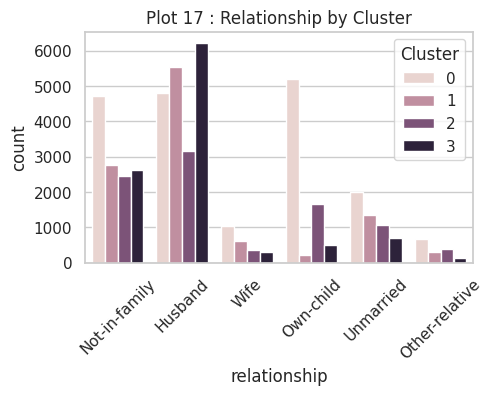

In [ ]:
# =========================================================
# PLOT 17 : RELATIONSHIP DISTRIBUTION
# =========================================================
plt.figure(figsize=(5,3))
sns.countplot(x='relationship',hue='Cluster',data=cluster_df
)
plt.xticks(rotation=45)
plt.title('Plot 17 : Relationship by Cluster')
plt.show()

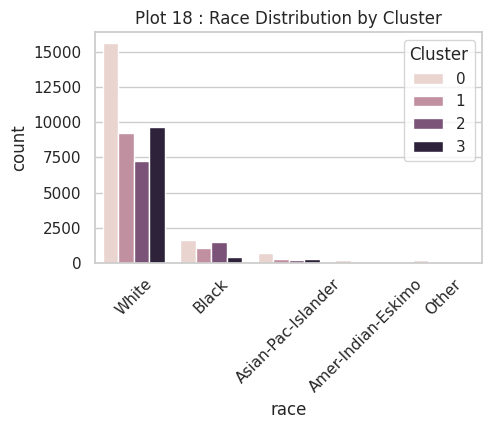

In [ ]:
# =========================================================
# PLOT 18 : RACE DISTRIBUTION
# =========================================================
plt.figure(figsize=(5,3))
sns.countplot(x='race',hue='Cluster',data=cluster_df
)
plt.xticks(rotation=45)
plt.title('Plot 18 : Race Distribution by Cluster')
plt.show()

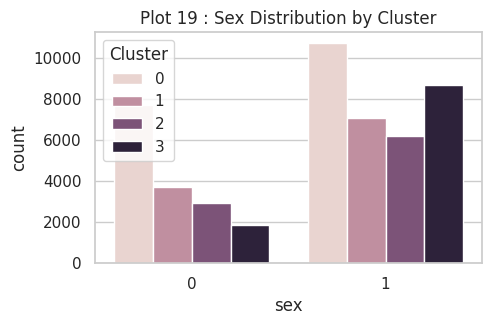

In [ ]:
# =========================================================
# PLOT 19 : SEX DISTRIBUTION
# =========================================================
plt.figure(figsize=(5,3))
sns.countplot(x='sex',hue='Cluster',data=cluster_df
)
plt.title('Plot 19 : Sex Distribution by Cluster')
plt.show()

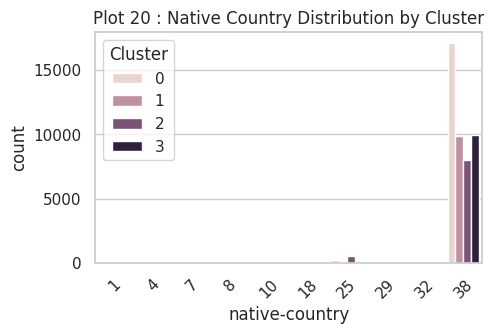

In [ ]:
# =========================================================
# PLOT 20 : NATIVE COUNTRY DISTRIBUTION
# =========================================================
# Top 10 countries only for readability
top_countries=cluster_df['native-country'].value_counts().head(10).index
country_df=cluster_df[cluster_df['native-country'].isin(top_countries)
]
plt.figure(figsize=(5,3))
sns.countplot(x='native-country',hue='Cluster',data=country_df
)
plt.xticks(rotation=45)
plt.title('Plot 20 : Native Country Distribution by Cluster')
plt.show()

In [ ]:
# =========================================================
# OPTIONAL : CLUSTER SUMMARY
# =========================================================
df_adult['Cluster'] = kmeans_labels # Ensure 'Cluster' column is defined from KMeans
cluster_summary=df_adult.groupby('Cluster')[num_cols].mean()
cluster_summary

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
Cluster,,,,,,
0,-0.646806,-0.448381,-0.025041,0.0,0.0,-0.508708
1,1.286446,-0.295335,-0.250128,0.0,0.0,-0.418784
2,-0.358760,1.494269,-0.197125,0.0,0.0,-0.230174
3,0.123460,-0.204089,0.469879,0.0,0.0,1.516177


In [ ]:
# =========================================================
# OPTIONAL : AGGLOMERATIVE CLUSTERING
# =========================================================
from sklearn.decomposition import PCA

# Ensure pca_data is defined for Agglomerative Clustering if this cell is run independently
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X) # X is scaled_data from earlier cells

X_sample = pca_data[:5000]  # adjust size
agglo_labels = AgglomerativeClustering(n_clusters=4).fit_predict(X_sample)

# agglo = AgglomerativeClustering(n_clusters=4)
# agglo_labels = agglo.fit_predict(X)

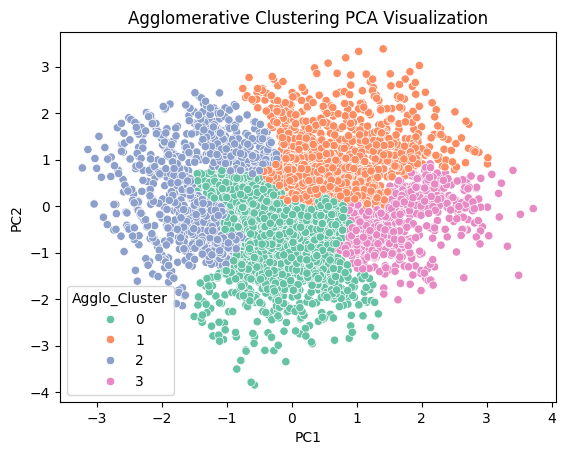

In [ ]:
# PCA Visualization for Agglomerative Clustering
pca_df_sampled = pd.DataFrame(pca_data[:5000], columns=['PC1', 'PC2'])
pca_df_sampled['Agglo_Cluster'] = agglo_labels

plt.figure()
sns.scatterplot(x='PC1',y='PC2',hue='Agglo_Cluster',palette='Set2',data=pca_df_sampled)
plt.title('Agglomerative Clustering PCA Visualization')
plt.show()

In [ ]:
# =================================================================================
# ==================Interpretation of Cluster Visualizations=======================
# =================================================================================
# ---------------------------------------------------------------------------------
# ---------------------Numerical Feature Visualizations----------------------------
# ---------------------------------------------------------------------------------
# - Age Distribution by Cluster
# - Identifies young professionals, middle-aged workers, and senior populations.
# - Hours-per-Week Distribution
# - Helps identify full-time, overtime, and part-time worker groups.
# - Education-num Distribution
# - Shows educational attainment differences across clusters.
# - Capital Gain/Loss Analysis
# - Detects financially strong or investment-oriented groups.
# - Final Weight (fnlwgt)
# - Indicates sampling representation differences.
# ---------------------------------------------------------------------------------
# --------------------Categorical Feature Visualizations---------------------------
# ---------------------------------------------------------------------------------
# - Workclass Distribution
# - Differentiates government workers, private employees, and self-employed groups.
# - Education Distribution
# - Reveals academic backgrounds of clusters.
# - Marital Status Distribution
# - Highlights family-oriented vs independent populations.
# - Occupation Distribution
# - Detects professional, labor, or service-oriented groups.
# - Relationship, Race, Sex, Native Country
# - Provides demographic composition insights.
# - Relationship, Race, Sex, Native Country
# - Provides demographic composition insights.
# =================================================================================

In [ ]:
# ================================================================
# ======================= Conclusion =============================
# ================================================================
# - The clustering visualizations reveal hidden socioeconomic
#    segments within the adult census population.
# - By analyzing demographic patterns, work behavior, education
#   level, and financial characteristics, policymakerscan:
#      - Design targeted welfare schemes
#      - Improve employment programs
#      - Develop financial literacy campaigns
#      - Understand labor-force segmentation
#      - Identify vulnerable population groups
# - PCA and t-SNE plots provide low-dimensional representations of
#   high-dimensional census data,enablingeasier interpretation of
#   cluster separation and group similarity.
# ================================================================

# IV) Interpretation & Profiling — Socioeconomic Group Discovery

1) For each cluster, describe the common demographic and work attributes

· Compare cluster distributions With the actual income (income column) if
needed (but not used in training)

· Suggest which groups might benefit from:

  o   Upskllling programs

  o   Tax reform

  o   Financial aid or inclusion efforts

In [ ]:
# After clustering using K-Means or Agglomerative Clustering, the next step is to:
#  understand each cluster
#  identify demographic/work patterns
#  connect findings to policy recommendations

## a) Add Cluster Labels to Dataset

In [ ]:
# For K-means
df_adult['Cluster'] = kmeans_labels

## b) Cluster Size Distribution

In [ ]:
# Check how many people belong to each cluster.

df_adult['Cluster'].value_counts()

,count
Cluster,
0,18418
1,10786
3,10540
2,9098


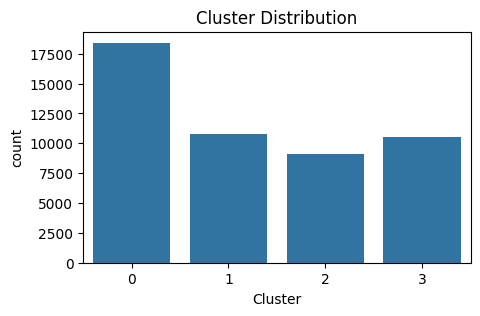

In [ ]:
# Visualize Cluster Distribution
plt.figure(figsize=(5,3))

sns.countplot(
    x='Cluster',
    data=df_adult
)

plt.title("Cluster Distribution")

plt.show()

## c) Numerical Feature Profiling

In [ ]:
# Analyze average numerical values per cluster.

cluster_profile = df_adult.groupby('Cluster')[
    ['age',
     'education-num',
     'hours-per-week',
     'capital-gain',
     'capital-loss']
].mean()

print(cluster_profile)

              age  education-num  hours-per-week  capital-gain  capital-loss
Cluster                                                                     
0       -0.646806      -0.025041       -0.508708           0.0           0.0
1        1.286446      -0.250128       -0.418784           0.0           0.0
2       -0.358760      -0.197125       -0.230174           0.0           0.0
3        0.123460       0.469879        1.516177           0.0           0.0


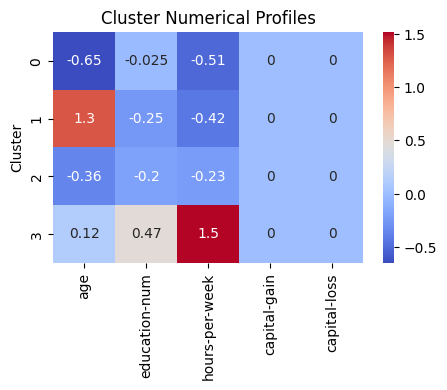

In [ ]:
# Heatmap of Cluster Profiles
plt.figure(figsize=(5,3))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap='coolwarm'
)

plt.title("Cluster Numerical Profiles")

plt.show()

## d) Categorical Feature Profiling

In [ ]:
cat_cols

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native-country',
 'income']

### i) Find dominant categories inside each cluster.

In [ ]:
workclass_cols = [col for col in df_adult.columns if col.startswith('workclass_')]
# Workclass Distribution
df_adult.groupby('Cluster')[workclass_cols].sum()

,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay
Cluster,,,,,,,,
0,431,971,8,15203,250,772,778,5
1,409,828,0,7661,392,1047,443,6
2,274,536,1,7364,148,441,332,2
3,232,638,0,7117,835,1389,324,5


In [ ]:
# Education Distribution
pd.crosstab(
    df_adult['Cluster'],
    df_adult['education']
)

education,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
Cluster,,,,,,,,,,,,,,,,
0,536,891,310,39,87,148,227,654,847,2954,83,5979,740,13,154,4756
1,436,356,120,111,211,541,286,233,397,1217,108,4068,560,34,154,1954
2,309,423,173,84,187,195,190,311,363,1171,61,3072,292,33,58,2176
3,108,142,54,13,24,71,53,403,454,2683,342,2665,1065,3,468,1992


In [ ]:
# Marital-status Distribution
pd.crosstab(
    df_adult['Cluster'],
    df_adult[ 'marital-status']
)

marital-status,0,1,2,3,4,5,6
Cluster,,,,,,,
0,2074,20,5980,216,9408,564,156
1,2046,3,6204,174,857,385,1117
2,1155,7,3617,138,3700,369,112
3,1358,7,6578,100,2152,212,133


In [ ]:
occupation_cols = [col for col in df_adult.columns if col.startswith('occupation_')]
# Occupation Distribution
df_adult.groupby('Cluster')[occupation_cols].sum()

,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving
Cluster,,,,,,,,,,,,,,
0,2445,7,2069,1490,343,990,1181,2311,74,4081,304,1898,606,619
1,1302,0,1339,1210,330,320,711,1009,91,2476,216,967,267,548
2,1101,3,1256,796,254,481,638,951,49,1792,201,852,284,440
3,481,5,1127,2275,503,186,344,386,20,2620,222,1514,226,631


In [ ]:
relationship_cols = [col for col in df_adult.columns if col.startswith('relationship_')]
# Relationship Distribution
df_adult.groupby('Cluster')[relationship_cols].sum()

,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
Cluster,,,,,,
0,4795,4722,684,5190,2000,1027
1,5540,2767,291,226,1349,613
2,3157,2459,391,1652,1066,373
3,6224,2635,140,513,710,318


In [ ]:
race_cols = [col for col in df_adult.columns if col.startswith('race_')]
# Race Distribution
df_adult.groupby('Cluster')[race_cols].sum()

,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White
Cluster,,,,,
0,253,715,1660,201,15589
1,105,306,1063,62,9250
2,37,209,1507,95,7250
3,75,289,455,48,9673


In [ ]:
# Sex Distribution
pd.crosstab(
    df_adult['Cluster'],
    df_adult[ 'sex']
)

sex,0,1
Cluster,,
0,7715,10703
1,3708,7078
2,2918,6180
3,1851,8689


In [ ]:
# Native-country Distribution
pd.crosstab(
    df_adult['Cluster'],
    df_adult[ 'native-country']
)

native-country,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
Cluster,,,,,,,,,,,,,,,,,,,,,
0,9,55,41,33,24,44,18,52,41,14,...,26,64,7,36,30,9,9,17086,47,6
1,5,51,34,25,53,24,12,25,26,8,...,22,64,11,21,2,8,7,9883,20,7
2,10,19,18,13,35,19,5,63,21,6,...,9,31,1,12,12,3,4,7990,12,4
3,2,45,24,10,20,14,8,7,34,8,...,9,16,1,37,17,9,5,9923,4,6


In [ ]:
# Income Distribution
pd.crosstab(
    df_adult['Cluster'],
    df_adult[ 'income']
)

income,0,1,2,3
Cluster,,,,
0,10609,5337,1662,810
1,5212,2677,1940,957
2,5004,2473,1085,536
3,3895,1948,3154,1543


## e) Compare Clusters with Income (Optional)

In [ ]:
# Income is NOT used in training, but can validate cluster quality.

pd.crosstab(
    df_adult['Cluster'],
    df_adult['income'],
    normalize='index'
) * 100

# This shows:

# percentage of high-income individuals per cluster
# socioeconomic separation quality

income,0,1,2,3
Cluster,,,,
0,57.601260,28.977088,9.023781,4.397872
1,48.321899,24.819210,17.986279,8.872613
2,55.001099,27.181798,11.925698,5.891405
3,36.954459,18.481973,29.924099,14.639469


In [ ]:
# ==============================================
# ==============================================
# ------Example Cluster Interpretation----------
# ==============================================
# ==============================================

In [ ]:

# Below is an example interpretation framework.

# ==============================================
# ------Cluster 0 — Low-Income Labor Group------
# ==============================================

# Characteristics
# ----------------
# Lower education-num
# Low capital-gain
# Moderate working hours
# Mostly manual/service occupations
# Higher proportion of younger workers

# Income Pattern
# --------------
# Majority earn ≤50K

# Policy Recommendations
# ----------------------
# ----------------------
# Upskilling Programs
# -------------------
# vocational training
# digital literacy
# trade certifications

# Financial Aid
# -------------
# subsidized education
# housing assistance
# healthcare inclusion

# Employment Support
# ------------------
# job placement programs
# workforce development initiatives

# ==============================================
# --Cluster 1 — Middle-Class Stable Workforce---
# ==============================================

# Characteristics
# ---------------
# Moderate education
# Stable employment
# Consistent working hours
# Clerical and technical occupations

# Income Pattern
# --------------
# Mixed income distribution

# Policy Recommendations
# ----------------------
# ----------------------
# Financial Literacy
# ------------------
# retirement planning
# investment education
# savings awareness

# Tax Reform
# -----------
# middle-income tax relief
# childcare tax credits

# Career Development
# ------------------
# professional certifications
# skill enhancement programs

# ==============================================
# ----Cluster 2 — High-Income Professionals-----
# ==============================================

# Characteristics
# ----------------
# Higher education-num
# Significant capital-gain
# Longer work hours
# Professional/managerial occupations

# Income Pattern
# --------------
# Majority >50K

# Policy Recommendations
# ----------------------
# ----------------------
# Tax Reform
# ----------
# progressive taxation analysis
# investment incentives

# Entrepreneurship Support
# ------------------------
# startup funding
# innovation grants

# Wealth Management
# -----------------
# retirement optimization
# investment diversification

# =====================================================
# Cluster 3 — Vulnerable / Economically Inactive Group
# =====================================================

# Characteristics
# ---------------
# Lower working hours
# Possible older age groups
# Lower employment participation
# Minimal capital-gain

# Income Pattern
# --------------
# Mostly lower-income

# Policy Recommendations
# ----------------------
# ----------------------
# Social Welfare
# --------------
# pension support
# healthcare access
# food assistance

# Inclusion Programs
# ------------------
# community employment
# social engagement initiatives

# Financial Inclusion
# -------------------
# banking access
# microfinance programs
# =====================================================

## f) Visualize Clusters in PCA Space



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


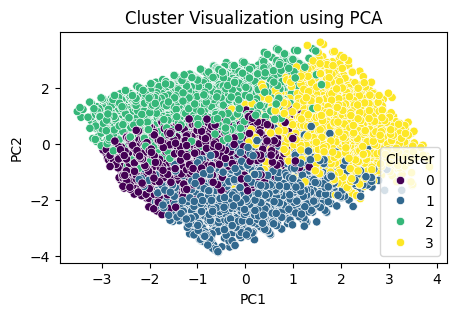

In [ ]:
# Using PCA components:

plt.figure(figsize=(5,3))

sns.scatterplot(
    x=pca_df['PC1'],
    y=pca_df['PC2'],
    hue=df_adult['Cluster'],
    palette='viridis'
)

plt.title("Cluster Visualization using PCA")

plt.show()

## g) Silhouette Score Interpretation

In [ ]:
# Evaluate cluster quality.

from sklearn.metrics import silhouette_score

score = silhouette_score(
    pca_data,
    df_adult['Cluster']
)

print(score)


# ==================================
# -----Silhouette Score Meaning-----
# ==================================
#  Score	       Interpretation
# ----------------------------------
#  Near 1	      Strong clustering
#  Near 0	     Overlapping clusters
# Negative	     Poor clustering
# ----------------------------------

0.14156300412481573


In [ ]:
# ---------------------------------------------
# Silhouette Score = 0.14156300412481573
# ---------------------------------------------
# Final Interpretation - Overlapping clusters
# ---------------------------------------------

In [ ]:
# ==================================================
# -----------Final Interpretation Goals-------------
# ==================================================
# # The purpose of cluster profiling is to identify:
  # - economically vulnerable populations
  # - stable working-class groups
  # - high-income professional segments
  # - financially excluded communities


In [ ]:
  # ==================================================================
  # ------------------------Policy Implications-----------------------
  # ==================================================================
  #---------Cluster Type-------------------Suggested Intervention-----
  # ------------------------------------------------------------------
  # - Low-income labor	             Upskilling & employment support
  # - Middle-income workers	         Tax relief & financial literacy
  # - High-income professionals	   Tax planning & investment incentives
  # - Vulnerable populations	          Welfare & inclusion programs

In [ ]:
# ========================================
# ----------Final Conclusion--------------
# ========================================

#  Using unsupervised learning:
# ------------------------------
# - hidden socioeconomic segments were identified
# - demographic and work patterns emerged naturally
# - clusters helped reveal:
#   - income inequality
#   - employment structures
#   - education disparities
#   - financial vulnerability

#  These insights can support:
# ------------------------------
# - evidence-based policymaking
# - targeted welfare allocation
# - employment program design
# - financial inclusion strategies.